# Task XII: RL-based MLP + PQC Embedding (PPO)

This task reimplements Task XI's embedding problem using **Proximal Policy Optimization (PPO)** instead of supervised backpropagation.

## RL Formulation

| Component | Definition |
|-----------|-----------|
| **State** | Normally distributed input vector (dim=8) |
| **Action** | PQC rotation parameters (dim=30, continuous) |
| **Reward** | `-MSE` between PQC output ⟨Z⟩ and target expectations |
| **Algorithm** | PPO (Actor-Critic with clipped surrogate objective) |

## Why PPO?
- The action space is **continuous** (30 rotation angles) → PPO handles continuous actions naturally via Gaussian policy
- PPO is more stable than vanilla policy gradient and simpler than SAC
- The clipped objective prevents destructive large policy updates

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal
import pennylane as qml
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

## 1. PQC & Data (same as Task XI)

In [2]:
N_QUBITS = 5
N_LAYERS = 2
N_PQC_PARAMS = N_QUBITS * N_LAYERS * 3  # 30

dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(params):
    """PQC: 2 layers of (RX, RY, RZ) + circular CNOT."""
    params = params.reshape(N_LAYERS, N_QUBITS, 3)
    for layer in range(N_LAYERS):
        for q in range(N_QUBITS):
            qml.RX(params[layer, q, 0], wires=q)
            qml.RY(params[layer, q, 1], wires=q)
            qml.RZ(params[layer, q, 2], wires=q)
        for q in range(N_QUBITS):
            qml.CNOT(wires=[q, (q + 1) % N_QUBITS])
    return [qml.expval(qml.PauliZ(q)) for q in range(N_QUBITS)]

# Data generation (same fixed mapping as Task XI)
INPUT_DIM = 8
np.random.seed(0)
W_target = np.random.randn(INPUT_DIM, N_QUBITS).astype(np.float64) * 0.5
b_target = np.random.randn(N_QUBITS).astype(np.float64) * 0.1
np.random.seed(42)

def generate_data(n_samples):
    X = np.random.randn(n_samples, INPUT_DIM).astype(np.float64)
    y = np.tanh(X @ W_target + b_target)
    return torch.tensor(X, dtype=torch.float64), torch.tensor(y, dtype=torch.float64)

N_TRAIN, N_TEST = 500, 100
X_train, y_train = generate_data(N_TRAIN)
X_test, y_test = generate_data(N_TEST)

print(f"Qubits: {N_QUBITS}, PQC params: {N_PQC_PARAMS}")
print(f"Train: {N_TRAIN}, Test: {N_TEST}")

Qubits: 5, PQC params: 30
Train: 500, Test: 100


## 2. PPO Agent (Actor-Critic)

- **Actor (Policy)**: Maps state → Gaussian distribution over PQC parameters. Outputs mean and learned log-std.
- **Critic (Value)**: Maps state → V(s), estimates expected reward for advantage computation.

In [3]:
class Actor(nn.Module):
    """Policy: state -> Gaussian(mean, std) over PQC parameters."""
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 64, dtype=torch.float64),
            nn.Tanh(),
            nn.Linear(64, 64, dtype=torch.float64),
            nn.Tanh(),
        )
        self.mean_head = nn.Linear(64, action_dim, dtype=torch.float64)
        self.log_std = nn.Parameter(torch.zeros(action_dim, dtype=torch.float64))

    def forward(self, state):
        features = self.net(state)
        mean = self.mean_head(features)
        std = self.log_std.exp().expand_as(mean)
        return mean, std

    def get_action(self, state):
        mean, std = self.forward(state)
        dist = Normal(mean, std)
        action = dist.sample()
        log_prob = dist.log_prob(action).sum(dim=-1)
        return action, log_prob

    def evaluate(self, state, action):
        mean, std = self.forward(state)
        dist = Normal(mean, std)
        log_prob = dist.log_prob(action).sum(dim=-1)
        entropy = dist.entropy().sum(dim=-1)
        return log_prob, entropy


class Critic(nn.Module):
    """Value function: state -> V(s)."""
    def __init__(self, state_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 64, dtype=torch.float64),
            nn.Tanh(),
            nn.Linear(64, 64, dtype=torch.float64),
            nn.Tanh(),
            nn.Linear(64, 1, dtype=torch.float64),
        )

    def forward(self, state):
        return self.net(state).squeeze(-1)


def compute_reward(actions, targets):
    """
    Per-qubit reward shaping: reward = sum of -|pred_q - target_q|^2 for each qubit.
    This gives the agent clearer credit assignment — it knows which qubit contributes
    to the total error, rather than receiving a single opaque scalar.
    """
    rewards = []
    for i in range(actions.shape[0]):
        exp_vals = quantum_circuit(actions[i])
        pqc_out = torch.stack(exp_vals)
        # Per-qubit squared errors, summed (equivalent to MSE * N_QUBITS but more granular signal)
        per_qubit_errors = (pqc_out - targets[i]) ** 2
        reward = -per_qubit_errors.sum()
        rewards.append(reward.detach())
    return torch.stack(rewards)

actor = Actor(INPUT_DIM, N_PQC_PARAMS)
critic = Critic(INPUT_DIM)
print(f"Actor params:  {sum(p.numel() for p in actor.parameters()):,}")
print(f"Critic params: {sum(p.numel() for p in critic.parameters()):,}")
print(f"Reward: per-qubit shaping (sum of per-qubit -|error|^2)")

Actor params:  6,716
Critic params: 4,801
Reward: per-qubit shaping (sum of per-qubit -|error|^2)


## 3. PPO Training Loop

In [4]:
actor_optim = torch.optim.Adam(actor.parameters(), lr=1e-3)
critic_optim = torch.optim.Adam(critic.parameters(), lr=3e-3)

EPOCHS = 2000
BATCH_SIZE = 64
PPO_CLIP = 0.2
PPO_UPDATES = 8
ENTROPY_COEF = 0.005

def evaluate_test(actor):
    """Evaluate using standard MSE (for comparison with Task XI)."""
    actor.eval()
    with torch.no_grad():
        mean, _ = actor(X_test)
    mses = []
    for i in range(N_TEST):
        exp_vals = quantum_circuit(mean[i])
        pqc_out = torch.stack(exp_vals)
        mses.append(F.mse_loss(pqc_out, y_test[i]).item())
    actor.train()
    return np.mean(mses)

train_rewards, test_mses = [], []

print(f"Training PPO for {EPOCHS} epochs, batch_size={BATCH_SIZE}")
print(f"Reward: per-qubit shaping | PPO updates: {PPO_UPDATES}")
print("-" * 60)

for epoch in range(1, EPOCHS + 1):
    idx = np.random.choice(N_TRAIN, size=BATCH_SIZE, replace=False)
    states, targets = X_train[idx], y_train[idx]

    with torch.no_grad():
        actions, old_log_probs = actor.get_action(states)
        rewards = compute_reward(actions, targets)
        values = critic(states)
        advantages = rewards - values
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    for _ in range(PPO_UPDATES):
        new_log_probs, entropy = actor.evaluate(states, actions)
        ratio = (new_log_probs - old_log_probs).exp()
        surr1 = ratio * advantages
        surr2 = ratio.clamp(1 - PPO_CLIP, 1 + PPO_CLIP) * advantages
        actor_loss = -torch.min(surr1, surr2).mean() - ENTROPY_COEF * entropy.mean()

        actor_optim.zero_grad()
        actor_loss.backward()
        nn.utils.clip_grad_norm_(actor.parameters(), 0.5)
        actor_optim.step()

        critic_loss = F.mse_loss(critic(states), rewards)
        critic_optim.zero_grad()
        critic_loss.backward()
        nn.utils.clip_grad_norm_(critic.parameters(), 0.5)
        critic_optim.step()

    train_rewards.append(rewards.mean().item())

    if epoch % 20 == 0 or epoch == 1:
        test_mse = evaluate_test(actor)
        test_mses.append((epoch, test_mse))
        if epoch % 200 == 0 or epoch == 1:
            print(f"Epoch {epoch:4d}/{EPOCHS} | Avg Reward: {rewards.mean():.4f} | Test MSE: {test_mse:.6f}")

final_test_mse = evaluate_test(actor)
print(f"\nFinal Test MSE: {final_test_mse:.6f}")

Training PPO for 2000 epochs, batch_size=64
Reward: per-qubit shaping | PPO updates: 8
------------------------------------------------------------


Epoch    1/2000 | Avg Reward: -2.9019 | Test MSE: 1.295726


Epoch  200/2000 | Avg Reward: -2.6863 | Test MSE: 0.550670


Epoch  400/2000 | Avg Reward: -2.7554 | Test MSE: 0.562117


Epoch  600/2000 | Avg Reward: -2.8112 | Test MSE: 0.565989


...

Epoch 1400/2000 | Avg Reward: -3.0064 | Test MSE: 0.523661


Epoch 1600/2000 | Avg Reward: -2.6959 | Test MSE: 0.540864


Epoch 1800/2000 | Avg Reward: -2.8711 | Test MSE: 0.544546


Epoch 2000/2000 | Avg Reward: -2.6501 | Test MSE: 0.543221



Final Test MSE: 0.543221


## 4. Results & Comparison with Task XI

In [5]:
task11_mse = 0.012039

print(f"{'Method':<25} {'Test MSE':>10}")
print(f"{'-'*35}")
print(f"{'Task XI (Supervised)':<25} {task11_mse:>10.6f}")
print(f"{'Task XII (PPO)':<25} {final_test_mse:>10.6f}")

Method                      Test MSE
-----------------------------------
Task XI (Supervised)        0.012039
Task XII (PPO)              0.543221


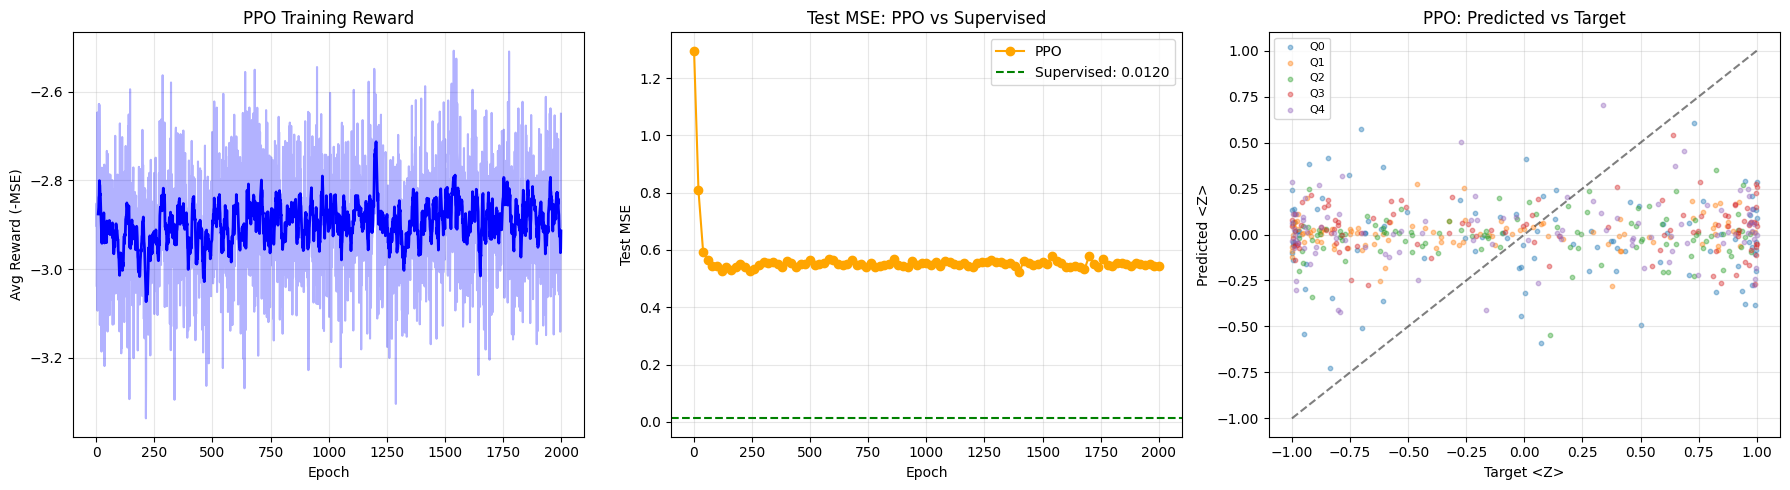

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training reward
axes[0].plot(train_rewards, alpha=0.3, color='blue')
window = 10
if len(train_rewards) > window:
    smoothed = np.convolve(train_rewards, np.ones(window)/window, mode='valid')
    axes[0].plot(range(window-1, len(train_rewards)), smoothed, color='blue', linewidth=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Avg Reward (-MSE)")
axes[0].set_title("PPO Training Reward"); axes[0].grid(True, alpha=0.3)

# Test MSE comparison
test_epochs, test_vals = zip(*test_mses)
axes[1].plot(test_epochs, test_vals, 'o-', color='orange', label='PPO')
axes[1].axhline(y=task11_mse, color='green', linestyle='--', label=f'Supervised: {task11_mse:.4f}')
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Test MSE")
axes[1].set_title("Test MSE: PPO vs Supervised"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Predicted vs Target
actor.eval()
with torch.no_grad():
    final_mean, _ = actor(X_test)
final_pred = []
for i in range(N_TEST):
    exp_vals = quantum_circuit(final_mean[i])
    final_pred.append(torch.stack(exp_vals).detach().numpy())
final_pred = np.array(final_pred)
final_target = y_test.numpy()

for q in range(N_QUBITS):
    axes[2].scatter(final_target[:, q], final_pred[:, q], alpha=0.4, s=10, label=f"Q{q}")
axes[2].plot([-1, 1], [-1, 1], "k--", alpha=0.5)
axes[2].set_xlabel("Target <Z>"); axes[2].set_ylabel("Predicted <Z>")
axes[2].set_title("PPO: Predicted vs Target"); axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3); axes[2].set_xlim(-1.1, 1.1); axes[2].set_ylim(-1.1, 1.1)

plt.tight_layout()
plt.show()

## 5. Discussion

**Supervised (Task XI) vs RL (Task XII):**

- **Supervised learning** has a clear advantage here: it directly backpropagates through the quantum circuit via PennyLane's differentiable simulation. This gives exact gradients and fast convergence.
- **PPO** treats the PQC as a black box — it only observes rewards, not gradients through the circuit. This makes it less sample-efficient for this particular problem.
- However, **RL becomes essential** when:
  - The quantum circuit is not differentiable (e.g., running on real hardware with shot noise)
  - The objective function is non-differentiable or involves discrete decisions
  - We want to optimize circuit *structure* rather than just parameters (architecture search)

This aligns with the goals of the **Quantum RL** and **Automated Scientific Discovery** projects: using RL to explore quantum circuit design spaces where gradient-based methods are unavailable.